# 🩺 Clasificación de mamografías: BENIGNO vs MALIGNO (CBIS-DDSM)

**Antes de empezar:** `Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU T4`. Luego `Entorno de ejecución → Ejecutar todas`.

**Qué hace este notebook**
1. Descarga CBIS-DDSM y usa **train y test oficiales** (el test nunca se toca hasta el final).
2. Deja **una fila por imagen** (una mamografía con varias lesiones se etiqueta MALIGNA si alguna lo es).
3. Separa entrenamiento/validación **por paciente** (sin fuga de datos) y elimina del train pacientes que están en test.
4. Pipeline `tf.data` rápido: escala de grises, resolución alta (512×320), orientación automática del seno, augmentation solo en train.
5. **EfficientNetB0** en dos fases (cabeza → fine-tuning con BatchNorm congelado), mixed precision, métricas AUC y sensibilidad.
6. Umbral elegido en validación para priorizar sensibilidad; evaluación final en test con AUC + intervalo de confianza.
7. Grad-CAM, prueba con tus propias imágenes y exportación (`.keras` + `config.json` + `preprocesamiento.py`) lista para tu web.

⏱️ Tiempo aproximado en T4: 35–50 min (la 1ª época es lenta porque decodifica las mamografías originales; después queda en caché).

> ⚠️ Herramienta académica / de apoyo. **No es un diagnóstico médico.**

## 1. Instalación e imports

In [1]:
!pip install -q kagglehub

import os, json, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import kagglehub

warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)
GPUS = tf.config.list_physical_devices('GPU')
print("GPU:", GPUS if GPUS else "⚠️ NO HAY GPU → Entorno de ejecución > Cambiar tipo > T4 GPU")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuración (lo único que normalmente tocarías)

In [2]:
SEED = 42

# 'FULL' = mamografía completa (lo que subirá el usuario en tu web)  ← recomendado
# 'ROI'  = solo la lesión recortada (más fácil y más AUC, pero el usuario tendría que recortar)
MODO = 'FULL'

IMG_H, IMG_W = (512, 320) if MODO == 'FULL' else (256, 256)   # mamografías son altas (~1.6:1)
BATCH_SIZE   = 16 if MODO == 'FULL' else 32

EPOCHS_HEAD  = 5       # fase 1: solo la cabeza
EPOCHS_FINE  = 20      # fase 2: fine-tuning (EarlyStopping corta antes si no mejora)
LR_HEAD      = 1e-3
LR_FINE      = 3e-5
PESOS_BASE   = 'imagenet'

SENSIBILIDAD_OBJETIVO = 0.85   # el umbral se elige para detectar al menos ~85% de malignos
USAR_MIXED_PRECISION  = True   # acelera ~2x en T4

GUARDAR_EN_DRIVE = False       # True = los modelos sobreviven si se cae la sesión
OUT_DIR = '/content/modelo_mamografia'

if GUARDAR_EN_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/modelo_mamografia'
os.makedirs(OUT_DIR, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)
if USAR_MIXED_PRECISION and GPUS:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("Política de precisión:", tf.keras.mixed_precision.global_policy().name)
print(f"Modo: {MODO} | Tamaño: {IMG_H}x{IMG_W} | Salida en: {OUT_DIR}")

Política de precisión: mixed_float16
Modo: FULL | Tamaño: 512x320 | Salida en: /content/modelo_mamografia


## 3. Descarga del dataset

In [3]:
base_path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")
CSV_DIR  = os.path.join(base_path, 'csv')
JPEG_DIR = os.path.join(base_path, 'jpeg')
assert os.path.isdir(CSV_DIR) and os.path.isdir(JPEG_DIR), f"Estructura inesperada: {os.listdir(base_path)}"
print("Ruta:", base_path)
print("CSVs:", sorted(os.listdir(CSV_DIR)))

100%|██████████| 4.95G/4.95G [00:56<00:00, 94.1MB/s]

Extracting files...


Ruta: /root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1
CSVs: ['calc_case_description_test_set.csv', 'calc_case_description_train_set.csv', 'dicom_info.csv', 'mass_case_description_test_set.csv', 'mass_case_description_train_set.csv', 'meta.csv']


## 4. Lectura de CSVs y vínculo con las imágenes JPEG

In [4]:
def extraer_uid(p):
    # '.../<study_uid>/<series_uid>/000000.dcm' -> series_uid
    partes = str(p).strip().replace('\\', '/').split('/')
    return partes[-2] if len(partes) >= 2 else None

def leer_csv(nombre, split):
    df = pd.read_csv(os.path.join(CSV_DIR, nombre))
    # normaliza nombres (calc usa 'breast density', mass usa 'breast_density', etc.)
    df.columns = df.columns.str.strip().str.lower().str.replace('_', ' ')
    df['split_oficial'] = split
    return df

casos = pd.concat([
    leer_csv('calc_case_description_train_set.csv', 'train'),
    leer_csv('mass_case_description_train_set.csv', 'train'),
    leer_csv('calc_case_description_test_set.csv',  'test'),
    leer_csv('mass_case_description_test_set.csv',  'test'),
], ignore_index=True)

casos['patient id'] = casos['patient id'].astype(str).str.strip()
casos['pathology']  = casos['pathology'].astype(str).str.strip().str.upper()
casos['label'] = (casos['pathology'] == 'MALIGNANT').astype(int)   # 1 = MALIGNO
print("Filas (lesiones) en CSVs:", len(casos))
print(casos.groupby(['split_oficial', 'pathology']).size(), "\n")

dicom = pd.read_csv(os.path.join(CSV_DIR, 'dicom_info.csv'))
dicom['SeriesDescription'] = dicom['SeriesDescription'].astype(str).str.strip().str.lower()
dicom['series_uid'] = dicom['image_path'].apply(extraer_uid)
dicom['ruta'] = [os.path.join(JPEG_DIR, uid, str(p).strip().split('/')[-1])
                 for uid, p in zip(dicom['series_uid'], dicom['image_path'])]
print(dicom['SeriesDescription'].value_counts())

Filas (lesiones) en CSVs: 3568
split_oficial  pathology              
test           BENIGN                      324
               BENIGN_WITHOUT_CALLBACK     104
               MALIGNANT                   276
train          BENIGN                     1105
               BENIGN_WITHOUT_CALLBACK     578
               MALIGNANT                  1181
dtype: int64 

SeriesDescription
cropped images           3567
roi mask images          3247
full mammogram images    2857
nan                       566
Name: count, dtype: int64


In [5]:
if MODO == 'FULL':
    DESCRIPCION, COLUMNA = 'full mammogram images', 'image file path'
else:
    DESCRIPCION, COLUMNA = 'cropped images', 'cropped image file path'

# Acepta también descripciones vacías ('nan'): en esta versión del dataset
# varias mamografías completas vienen sin SeriesDescription.
validas = [DESCRIPCION] if MODO == 'ROI' else [DESCRIPCION, 'nan']
cand = dicom[dicom['SeriesDescription'].isin(validas)].copy()
cand['prio'] = (cand['SeriesDescription'] != DESCRIPCION).astype(int)
mapa = cand.sort_values('prio').drop_duplicates('series_uid')[['series_uid', 'ruta']]
casos['series_uid'] = casos[COLUMNA].apply(extraer_uid)

df = casos.merge(mapa, on='series_uid', how='inner')
print(f"Lesiones vinculadas a una imagen: {len(df)} / {len(casos)}")
df = df[df['ruta'].apply(os.path.exists)].copy()
print(f"Con archivo existente en disco:   {len(df)}")

def parece_mascara(ruta):
    # Protección: descarta máscaras ROI que se cuelen mal etiquetadas.
    try:
        with Image.open(ruta) as im:
            im.draft('L', (128, 128))
            a = np.asarray(im.convert('L').resize((64, 64), Image.NEAREST))
        return np.mean((a < 5) | (a > 250)) > 0.95
    except Exception:
        return True

# Filtro de máscaras en ambos modos (tarda 1-3 minutos)
es_mask = df['ruta'].apply(parece_mascara)
print(f"Máscaras mal etiquetadas descartadas: {es_mask.sum()}")
df = df[~es_mask]

if len(df) == 0:
    raise RuntimeError("No se encontró ninguna imagen. Revisa JPEG_DIR y dicom_info.csv")

Lesiones vinculadas a una imagen: 3568 / 3568
Con archivo existente en disco:   3568
Máscaras mal etiquetadas descartadas: 0


In [6]:
# Diagnóstico: qué lesiones siguen sin imagen después de la corrección
sin_vinculo = casos[~casos['series_uid'].isin(mapa['series_uid'])]
print(f"Lesiones sin imagen: {len(sin_vinculo)}")
print(sin_vinculo.groupby(['split_oficial', 'abnormality type']).size())
print(dicom[dicom['series_uid'].isin(sin_vinculo['series_uid'])]['SeriesDescription'].value_counts())

Lesiones sin imagen: 0
Series([], dtype: int64)
Series([], Name: count, dtype: int64)


## 5. Una fila por imagen + split sin fuga de datos
- **FULL:** una fila por (paciente, seno, vista). Si alguna lesión de esa mamografía es maligna → MALIGNO.
- Pacientes que aparecen en test se eliminan del train (calc y mass tienen particiones distintas).
- Train → train/val con `StratifiedGroupKFold` agrupando por paciente.

In [7]:
if MODO == 'FULL':
    claves = ['split_oficial', 'patient id', 'left or right breast', 'image view']
else:
    claves = ['split_oficial', 'patient id', 'ruta']

agg = dict(label=('label', 'max'),
           n_lesiones=('label', 'size'),
           tipo=('abnormality type', lambda s: '+'.join(sorted(set(map(str, s))))))
if MODO == 'FULL':
    agg['ruta'] = ('ruta', 'first')

datos = df.groupby(claves, as_index=False).agg(**agg)
datos = datos.drop_duplicates(['split_oficial', 'ruta']).reset_index(drop=True)

pac_test = set(datos.loc[datos['split_oficial'] == 'test', 'patient id'])
fuga = (datos['split_oficial'] == 'train') & datos['patient id'].isin(pac_test)
print(f"Imágenes de train eliminadas por paciente compartido con test: {fuga.sum()}")
datos = datos[~fuga].reset_index(drop=True)

df_trainval = datos[datos['split_oficial'] == 'train'].reset_index(drop=True)
df_test     = datos[datos['split_oficial'] == 'test'].reset_index(drop=True)

sgkf = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
tr_idx, va_idx = next(sgkf.split(df_trainval, df_trainval['label'], groups=df_trainval['patient id']))
df_train = df_trainval.iloc[tr_idx].reset_index(drop=True)
df_val   = df_trainval.iloc[va_idx].reset_index(drop=True)

assert not set(df_train['patient id']) & set(df_val['patient id']),  "Fuga train/val"
assert not set(df_train['patient id']) & set(df_test['patient id']), "Fuga train/test"
assert not set(df_val['patient id'])   & set(df_test['patient id']), "Fuga val/test"
for nombre, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    assert d['label'].nunique() == 2, f"{nombre} no tiene ambas clases"

resumen = pd.DataFrame({n: d['label'].value_counts().rename({0: 'BENIGNO', 1: 'MALIGNO'})
                        for n, d in [('train', df_train), ('val', df_val), ('test', df_test)]}).T
resumen['total'] = resumen.sum(axis=1)
resumen['% maligno'] = (100 * resumen['MALIGNO'] / resumen['total']).round(1)
resumen['pacientes'] = [d['patient id'].nunique() for d in (df_train, df_val, df_test)]
print("✅ Sin fuga de pacientes entre conjuntos\n")
print(resumen)

Imágenes de train eliminadas por paciente compartido con test: 64
✅ Sin fuga de pacientes entre conjuntos

label  BENIGNO  MALIGNO  total  % maligno  pacientes
train     1086      881   1967       44.8       1014
val        205      184    389       47.3        203
test       379      262    641       40.9        349


## 6. Preprocesamiento (el MISMO se usará en la web)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

def preparar_desde_bytes(raw):
    # bytes (jpg/png, 8 o 16 bits) -> uint8 (IMG_H, IMG_W, 1)
    img = tf.io.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)            # 0-1 (sirve para 8 y 16 bits)
    img = tf.image.resize(img, (IMG_H, IMG_W), antialias=True) * 255.0
    if MODO == 'FULL':
        # Orientación: el seno siempre a la izquierda (lado más brillante)
        mitad = IMG_W // 2
        izq = tf.reduce_sum(img[:, :mitad])
        der = tf.reduce_sum(img[:, -mitad:])
        img = tf.cond(der > izq, lambda: tf.image.flip_left_right(img), lambda: img)
    img = tf.clip_by_value(tf.round(img), 0, 255)
    img.set_shape((IMG_H, IMG_W, 1))
    return tf.cast(img, tf.uint8)

def preparar(ruta):
    return preparar_desde_bytes(tf.io.read_file(ruta))

def a_entrada_modelo(img_u8_o_float):
    # (H,W,1) -> (H,W,3) float32 en 0-255. EfficientNet normaliza internamente.
    return tf.image.grayscale_to_rgb(tf.cast(img_u8_o_float, tf.float32))

def aumentar(img_u8):
    img = tf.cast(img_u8, tf.float32)
    escala = tf.random.uniform([], 0.85, 1.0)                  # zoom + traslación
    y0 = tf.random.uniform([], 0.0, 1.0 - escala)
    x0 = tf.random.uniform([], 0.0, 1.0 - escala)
    caja = tf.reshape(tf.stack([y0, x0, y0 + escala, x0 + escala]), (1, 4))
    img = tf.image.crop_and_resize(img[None], caja, [0], (IMG_H, IMG_W))[0]
    if MODO == 'ROI':
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 20.0)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    return tf.clip_by_value(img, 0.0, 255.0)

# pesos por clase (solo con train) -> se pasan como sample_weight
n_tot, n_pos = len(df_train), int(df_train['label'].sum())
PESOS_CLASE = {0: n_tot / (2 * (n_tot - n_pos)), 1: n_tot / (2 * n_pos)}
print("Pesos por clase:", {k: round(v, 3) for k, v in PESOS_CLASE.items()})

def crear_ds(d, entrenamiento):
    y = d['label'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((d['ruta'].values, y))
    ds = ds.map(lambda r, l: (preparar(r), l), num_parallel_calls=4).cache()
    if entrenamiento:
        w = tf.constant([PESOS_CLASE[0], PESOS_CLASE[1]], tf.float32)
        ds = ds.shuffle(len(d), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda x, l: (a_entrada_modelo(aumentar(x)), l, tf.gather(w, tf.cast(l, tf.int32))),
                    num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda x, l: (a_entrada_modelo(x), l), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = crear_ds(df_train, True)
val_ds   = crear_ds(df_val,   False)
test_ds  = crear_ds(df_test,  False)

Pesos por clase: {0: 0.906, 1: 1.116}


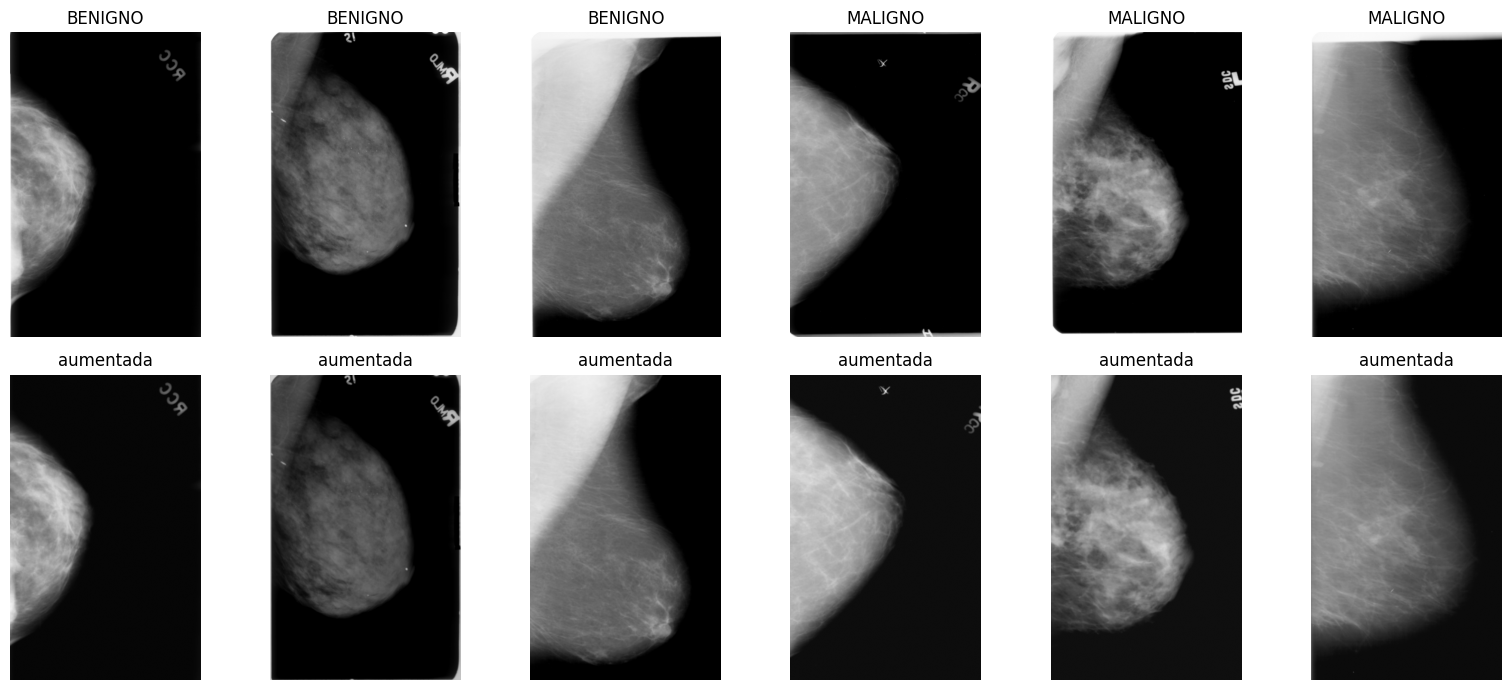

In [10]:
# Vista rápida: arriba como entran (preprocesadas), abajo con augmentation
muestra = pd.concat([df_train[df_train.label == 0].sample(3, random_state=SEED),
                     df_train[df_train.label == 1].sample(3, random_state=SEED)])
fig, ax = plt.subplots(2, 6, figsize=(16, 7))
for i, (_, r) in enumerate(muestra.iterrows()):
    img = preparar(r['ruta'])
    ax[0, i].imshow(img[..., 0], cmap='gray'); ax[0, i].set_title('MALIGNO' if r.label else 'BENIGNO')
    ax[1, i].imshow(aumentar(img)[..., 0], cmap='gray', vmin=0, vmax=255); ax[1, i].set_title('aumentada')
    ax[0, i].axis('off'); ax[1, i].axis('off')
plt.tight_layout(); plt.show()

## 7. Modelo (EfficientNetB0, API funcional, BatchNorm en modo inferencia)

In [11]:
def construir_modelo(pesos=PESOS_BASE):
    base = tf.keras.applications.EfficientNetB0(include_top=False, weights=pesos,
                                                input_shape=(IMG_H, IMG_W, 3))
    base.trainable = False
    entradas = tf.keras.Input(shape=(IMG_H, IMG_W, 3), name='imagen')
    x = base(entradas, training=False)          # BN nunca actualiza estadísticas
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.4, name='dropout')(x)
    salida = layers.Dense(1, activation='sigmoid', dtype='float32', name='prob_maligno')(x)
    return tf.keras.Model(entradas, salida, name='clasificador_mamografia'), base

def metricas():
    return [tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='sensibilidad'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.BinaryAccuracy(name='accuracy')]

model, base = construir_modelo()
model.compile(optimizer=tf.keras.optimizers.Adam(LR_HEAD),
              loss='binary_crossentropy', metrics=metricas())
model.summary()
CKPT = os.path.join(OUT_DIR, 'mejor_modelo.keras')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "clasificador_mamografia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 512, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 16, 10, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob_maligno (Dense)            │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 8. Fase 1 — entrenar solo la cabeza

In [12]:
cb1 = [
    tf.keras.callbacks.ModelCheckpoint(CKPT, monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True),
]
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=cb1)
MEJOR_AUC_F1 = max(h1.history['val_auc'])
print(f"Mejor val AUC fase 1: {MEJOR_AUC_F1:.4f}")

Epoch 1/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.5143 - auc: 0.5226 - loss: 0.7040 - precision: 0.4595 - sensibilidad: 0.5264
Epoch 1: val_auc improved from None to 0.63106, saving model to /content/modelo_mamografia/mejor_modelo.keras

Epoch 1: finished saving model to /content/modelo_mamografia/mejor_modelo.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 373s 1s/step - accuracy: 0.5211 - auc: 0.5388 - loss: 0.6984 - precision: 0.4690 - sensibilidad: 0.5244 - val_accuracy: 0.5835 - val_auc: 0.6311 - val_loss: 0.6680 - val_precision: 0.5632 - val_sensibilidad: 0.5326
Epoch 2/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5537 - auc: 0.5922 - loss: 0.6800 - precision: 0.5121 - sensibilidad: 0.5857
Epoch 2: val_auc improved from 0.63106 to 0.66922, saving model to /content/modelo_mamografia/mejor_modelo.keras

Epoch 2: finished saving model to /content/modelo_mamografia/mejor_modelo.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.5648 - auc: 0.5882 - loss: 

## 9. Fase 2 — fine-tuning (bloques 4–7 descongelados, BatchNorm congelado)

In [13]:
base.trainable = True
nombres = [l.name for l in base.layers]
corte = next((i for i, n in enumerate(nombres) if n.startswith('block4a')), len(nombres) - 100)
for i, capa in enumerate(base.layers):
    capa.trainable = (i >= corte) and not isinstance(capa, layers.BatchNormalization)
print(f"Capas entrenables en la base: {sum(c.trainable for c in base.layers)} / {len(base.layers)}")

model.compile(optimizer=tf.keras.optimizers.Adam(LR_FINE),
              loss='binary_crossentropy', metrics=metricas())
cb2 = [
    # initial_value_threshold: solo sobrescribe si SUPERA lo mejor de la fase 1
    tf.keras.callbacks.ModelCheckpoint(CKPT, monitor='val_auc', mode='max', save_best_only=True,
                                       initial_value_threshold=MEJOR_AUC_F1, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=2,
                                         min_lr=1e-7, verbose=1),
]
ep1 = len(h1.history['loss'])
h2 = model.fit(train_ds, validation_data=val_ds, epochs=ep1 + EPOCHS_FINE,
               initial_epoch=ep1, callbacks=cb2)

Capas entrenables en la base: 128 / 238
Epoch 6/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.5989 - auc: 0.6327 - loss: 0.6671 - precision: 0.5550 - sensibilidad: 0.6716
Epoch 6: val_auc improved from 0.69829 to 0.72725, saving model to /content/modelo_mamografia/mejor_modelo.keras

Epoch 6: finished saving model to /content/modelo_mamografia/mejor_modelo.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.6207 - auc: 0.6594 - loss: 0.6540 - precision: 0.5652 - sensibilidad: 0.6640 - val_accuracy: 0.6350 - val_auc: 0.7273 - val_loss: 0.6316 - val_precision: 0.7442 - val_sensibilidad: 0.3478 - learning_rate: 3.0000e-05
Epoch 7/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6422 - auc: 0.6822 - loss: 0.6451 - precision: 0.6127 - sensibilidad: 0.5523
Epoch 7: val_auc improved from 0.72725 to 0.74545, saving model to /content/modelo_mamografia/mejor_modelo.keras

Epoch 7: finished saving model to /content/modelo_mamografia/mejor_modelo.keras
123/123 ━━━

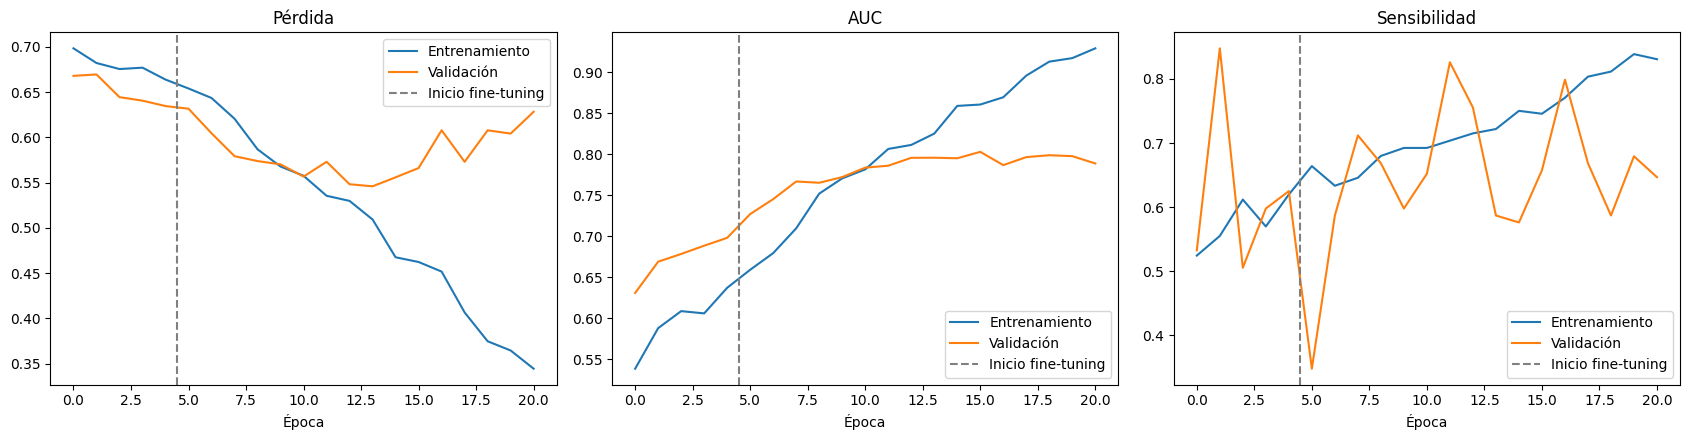

✅ Cargado el mejor modelo: /content/modelo_mamografia/mejor_modelo.keras


In [14]:
hist = {k: h1.history[k] + h2.history.get(k, []) for k in h1.history}
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for a, m, t in zip(ax, ['loss', 'auc', 'sensibilidad'], ['Pérdida', 'AUC', 'Sensibilidad']):
    a.plot(hist[m], label='Entrenamiento'); a.plot(hist['val_' + m], label='Validación')
    a.axvline(ep1 - 0.5, color='gray', ls='--', label='Inicio fine-tuning')
    a.set_title(t); a.set_xlabel('Época'); a.legend()
plt.tight_layout(); plt.show()

model = tf.keras.models.load_model(CKPT)   # el mejor según val AUC
print("✅ Cargado el mejor modelo:", CKPT)

## 10. Umbral (elegido en validación) y evaluación final en TEST
El test solo se usa aquí. El umbral **no** es 0.5: se elige en validación para alcanzar la sensibilidad objetivo.

In [15]:
p_val  = model.predict(val_ds,  verbose=0).ravel().astype('float64')
p_test = model.predict(test_ds, verbose=0).ravel().astype('float64')
y_val, y_test = df_val['label'].values, df_test['label'].values

fpr_v, tpr_v, thr_v = roc_curve(y_val, p_val)
thr_v = np.clip(thr_v, 0, 1)
UMBRAL_YOUDEN = float(thr_v[1:][np.argmax((tpr_v - fpr_v)[1:])])   # [1:] ignora el umbral 'infinito'
UMBRAL = float(thr_v[np.argmax(tpr_v >= SENSIBILIDAD_OBJETIVO)])
print(f"Umbral para sensibilidad ≥{SENSIBILIDAD_OBJETIVO:.0%}: {UMBRAL:.4f} | Umbral Youden: {UMBRAL_YOUDEN:.4f}")

def auc_ic(y, p, n=1000):
    rng, vals = np.random.default_rng(SEED), []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) == 2:
            vals.append(roc_auc_score(y[i], p[i]))
    return np.percentile(vals, [2.5, 97.5])

def reporte(y, p, umbral, nombre):
    auc = roc_auc_score(y, p); lo, hi = auc_ic(y, p)
    tn, fp, fn, tp = confusion_matrix(y, (p >= umbral).astype(int), labels=[0, 1]).ravel()
    r = {'AUC': auc, 'AUC_IC95': [float(lo), float(hi)],
         'sensibilidad': tp / (tp + fn), 'especificidad': tn / (tn + fp),
         'VPP': tp / (tp + fp) if tp + fp else 0.0, 'VPN': tn / (tn + fn) if tn + fn else 0.0,
         'accuracy': (tp + tn) / len(y), 'n': int(len(y))}
    print(f"\n=== {nombre} (umbral {umbral:.3f}) ===")
    print(f"AUC: {auc:.4f}  (IC95%: {lo:.3f}–{hi:.3f})")
    for k in ['sensibilidad', 'especificidad', 'VPP', 'VPN', 'accuracy']:
        print(f"{k:>14}: {r[k]:.3f}")
    return r, np.array([[tn, fp], [fn, tp]])

r_val, _       = reporte(y_val,  p_val,  UMBRAL, 'VALIDACIÓN')
r_test, cm_test = reporte(y_test, p_test, UMBRAL, 'TEST OFICIAL (resultado final)')

if 'tipo' in df_test:
    print("\nAUC en test por tipo de lesión:")
    for t, g in df_test.assign(p=p_test).groupby('tipo'):
        if g['label'].nunique() == 2:
            print(f"  {t:<25} n={len(g):4d}  AUC={roc_auc_score(g['label'], g['p']):.3f}")

Umbral para sensibilidad ≥85%: 0.2768 | Umbral Youden: 0.3465

=== VALIDACIÓN (umbral 0.277) ===
AUC: 0.8031  (IC95%: 0.756–0.844)
  sensibilidad: 0.853
 especificidad: 0.580
           VPP: 0.646
           VPN: 0.815
      accuracy: 0.710

=== TEST OFICIAL (resultado final) (umbral 0.277) ===
AUC: 0.7657  (IC95%: 0.728–0.801)
  sensibilidad: 0.855
 especificidad: 0.496
           VPP: 0.540
           VPN: 0.832
      accuracy: 0.643

AUC en test por tipo de lesión:
  calcification             n= 280  AUC=0.706
  mass                      n= 357  AUC=0.821


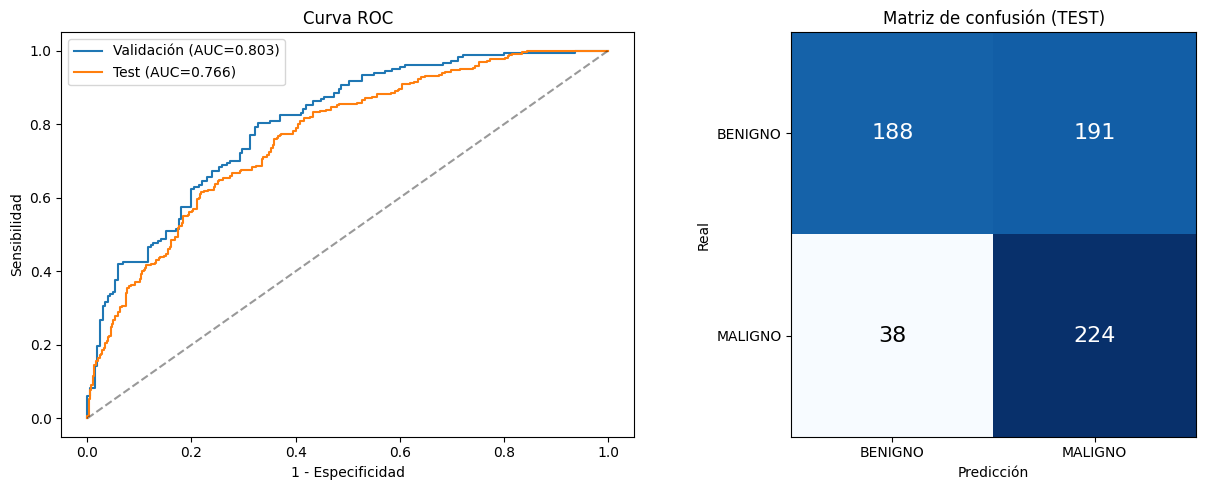

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for y, p, n in [(y_val, p_val, 'Validación'), (y_test, p_test, 'Test')]:
    f, t, _ = roc_curve(y, p); ax[0].plot(f, t, label=f"{n} (AUC={roc_auc_score(y, p):.3f})")
ax[0].plot([0, 1], [0, 1], 'k--', alpha=.4)
ax[0].set_xlabel('1 - Especificidad'); ax[0].set_ylabel('Sensibilidad'); ax[0].set_title('Curva ROC'); ax[0].legend()

ax[1].imshow(cm_test, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, cm_test[i, j], ha='center', va='center', fontsize=16,
                   color='white' if cm_test[i, j] > cm_test.max() / 2 else 'black')
ax[1].set_xticks([0, 1], ['BENIGNO', 'MALIGNO']); ax[1].set_yticks([0, 1], ['BENIGNO', 'MALIGNO'])
ax[1].set_xlabel('Predicción'); ax[1].set_ylabel('Real'); ax[1].set_title('Matriz de confusión (TEST)')
plt.tight_layout(); plt.show()

## 11. Grad-CAM y función de predicción (igual a la que usará tu web)

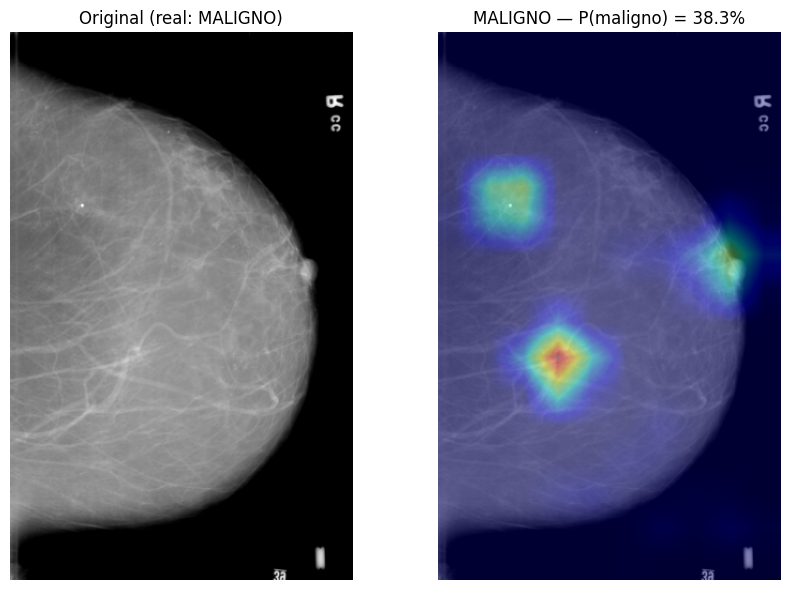

{'prediccion': 'MALIGNO', 'prob_maligno': 0.38344550132751465, 'umbral': 0.2768046259880066}


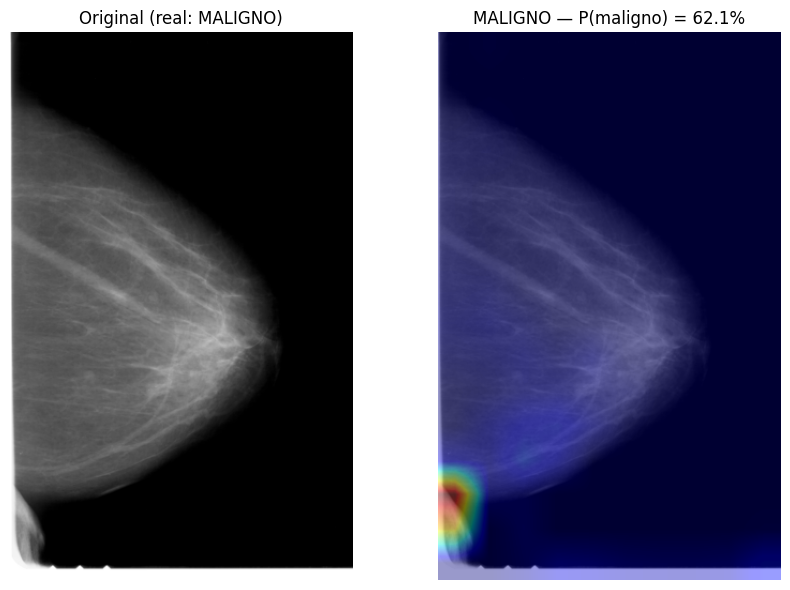

{'prediccion': 'MALIGNO', 'prob_maligno': 0.6208823323249817, 'umbral': 0.2768046259880066}


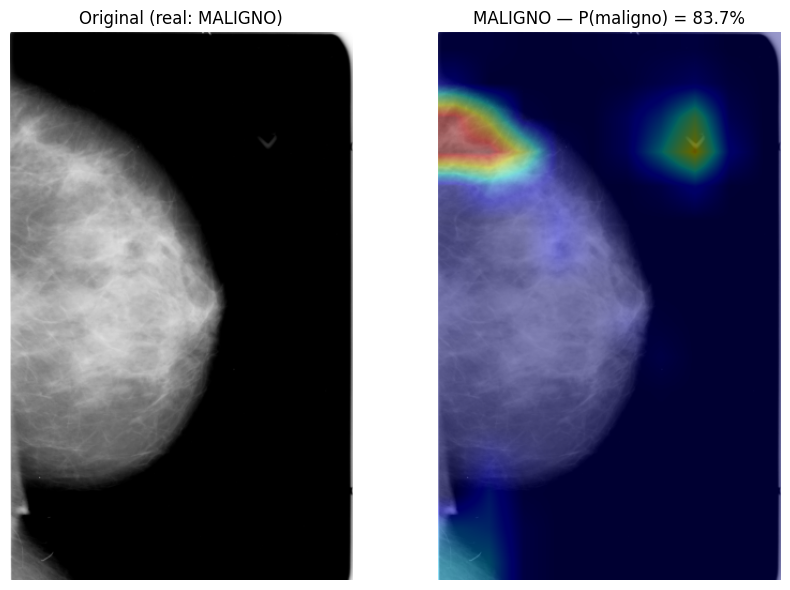

{'prediccion': 'MALIGNO', 'prob_maligno': 0.8365082740783691, 'umbral': 0.2768046259880066}


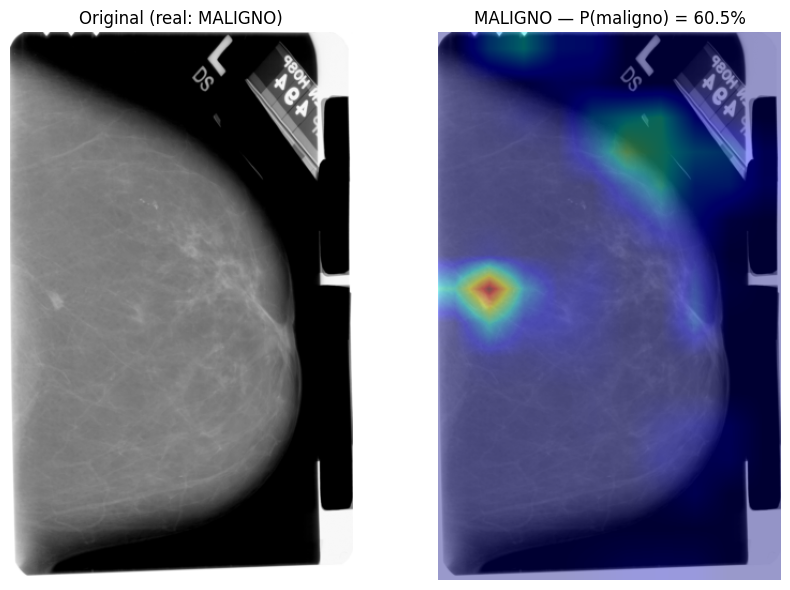

{'prediccion': 'MALIGNO', 'prob_maligno': 0.6046232581138611, 'umbral': 0.2768046259880066}


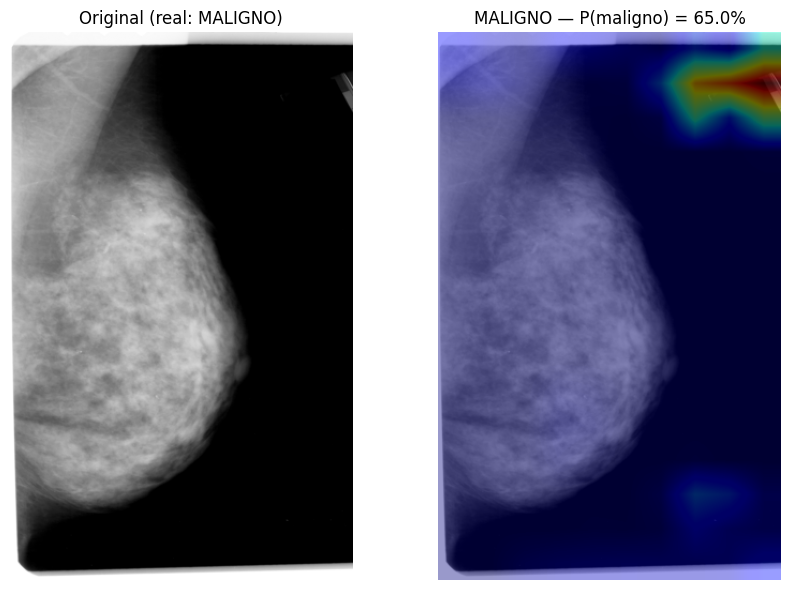

{'prediccion': 'MALIGNO', 'prob_maligno': 0.6503012776374817, 'umbral': 0.2768046259880066}


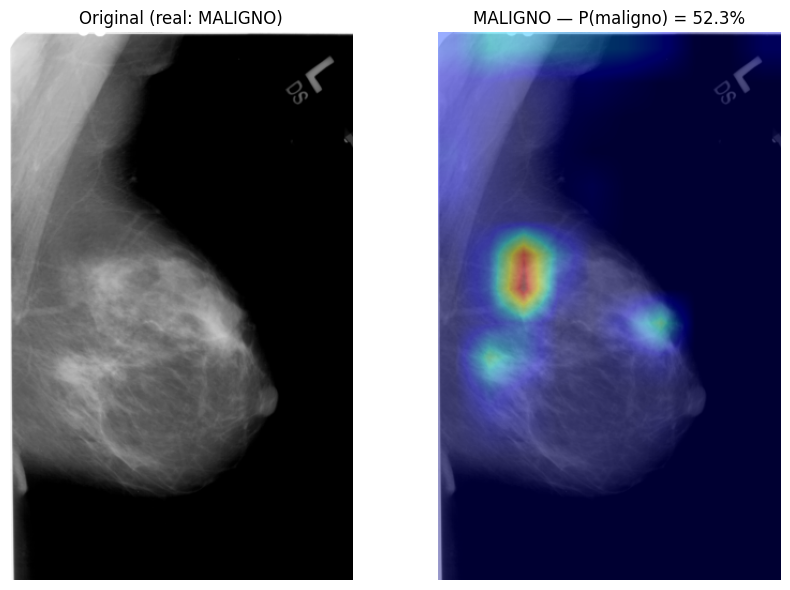

{'prediccion': 'MALIGNO', 'prob_maligno': 0.5229510068893433, 'umbral': 0.2768046259880066}


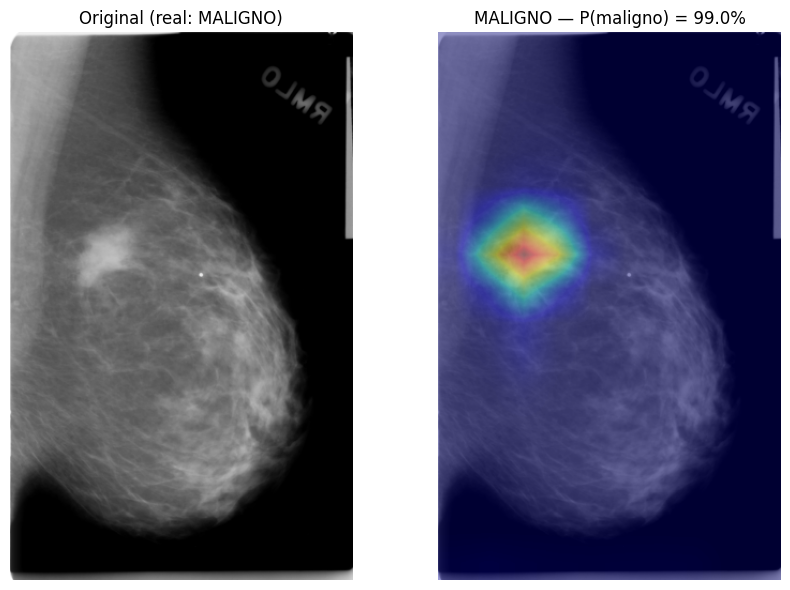

{'prediccion': 'MALIGNO', 'prob_maligno': 0.9900808930397034, 'umbral': 0.2768046259880066}


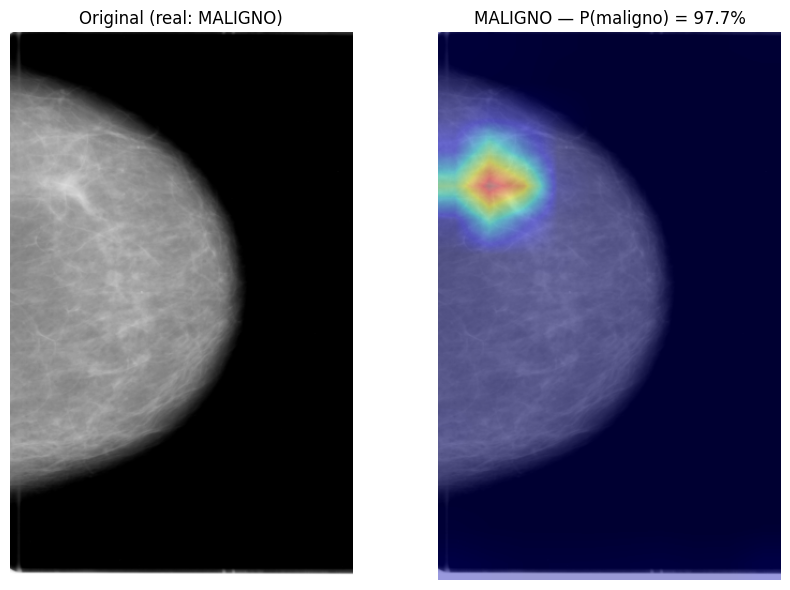

{'prediccion': 'MALIGNO', 'prob_maligno': 0.977123498916626, 'umbral': 0.2768046259880066}


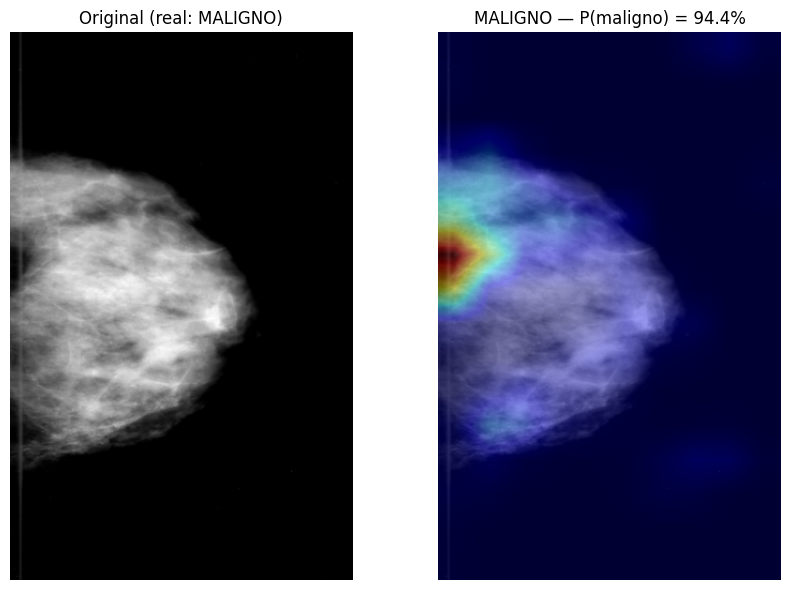

{'prediccion': 'MALIGNO', 'prob_maligno': 0.9438309669494629, 'umbral': 0.2768046259880066}


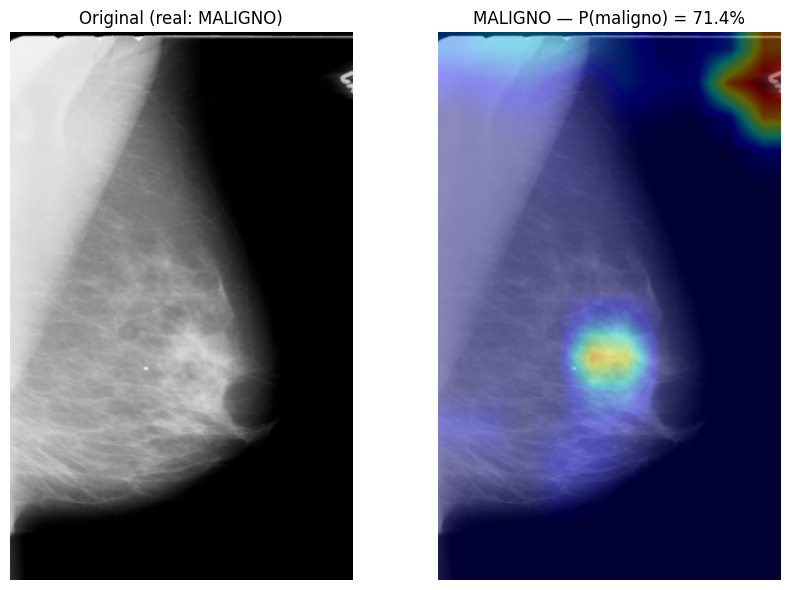

{'prediccion': 'MALIGNO', 'prob_maligno': 0.7137778401374817, 'umbral': 0.2768046259880066}


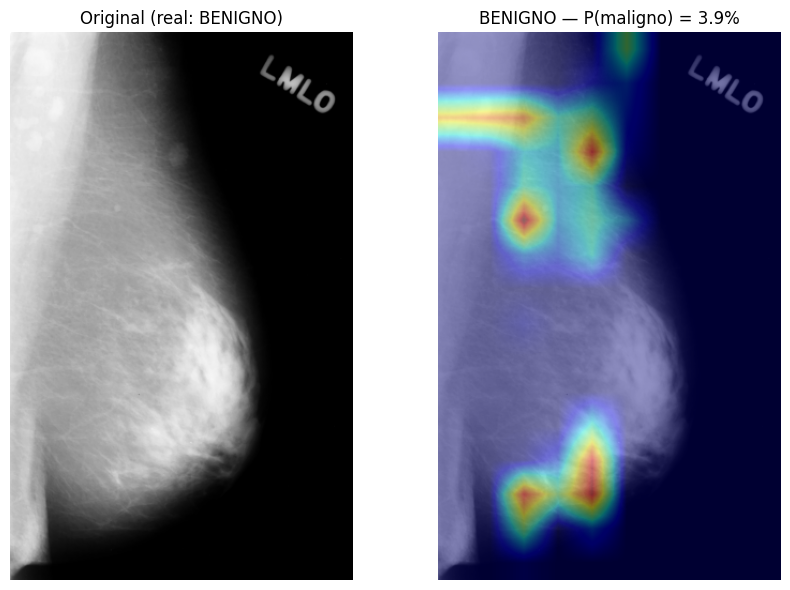

{'prediccion': 'BENIGNO', 'prob_maligno': 0.03934932500123978, 'umbral': 0.2768046259880066}


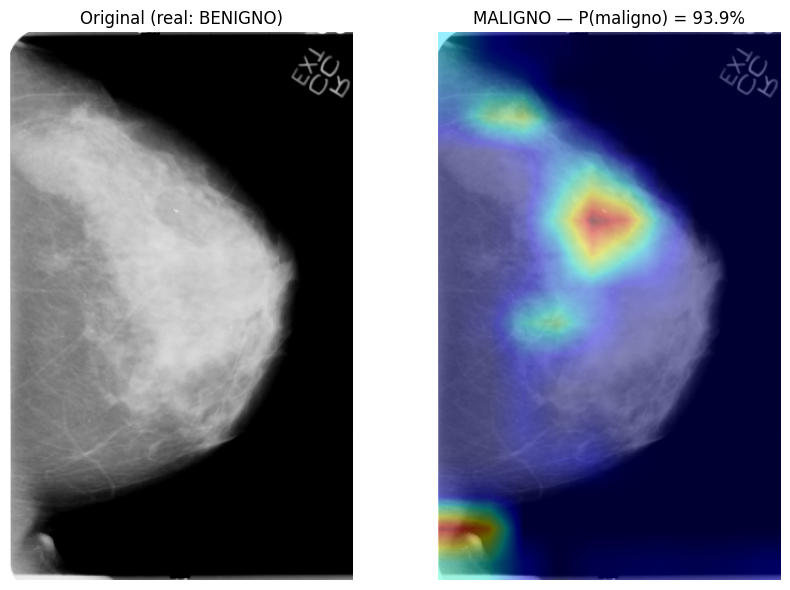

{'prediccion': 'MALIGNO', 'prob_maligno': 0.938601553440094, 'umbral': 0.2768046259880066}


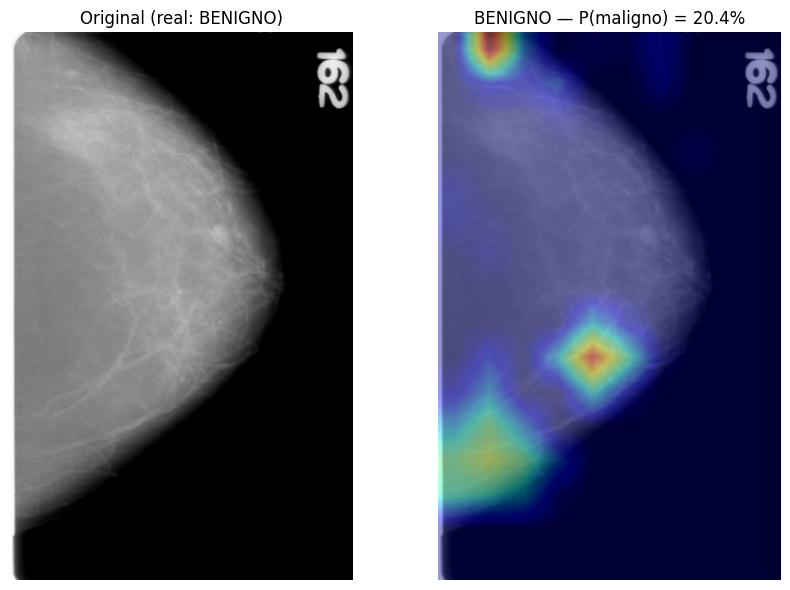

{'prediccion': 'BENIGNO', 'prob_maligno': 0.20441874861717224, 'umbral': 0.2768046259880066}


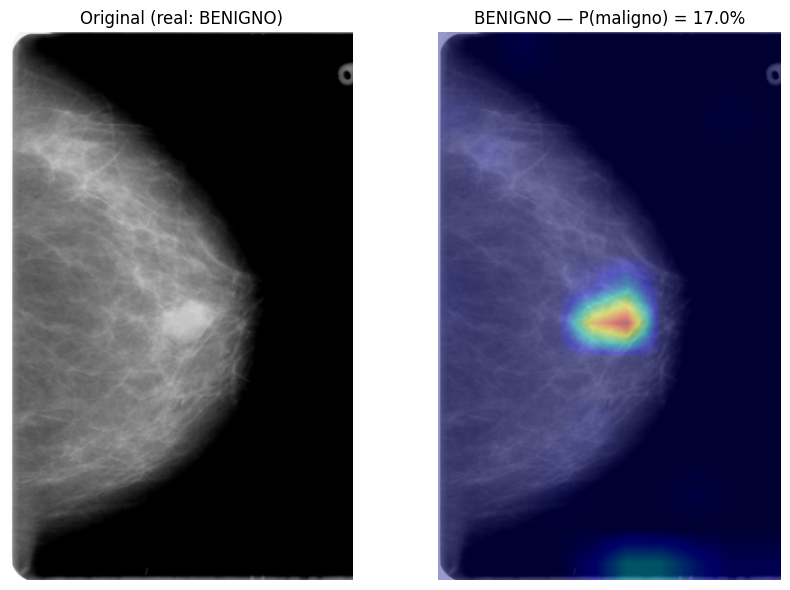

{'prediccion': 'BENIGNO', 'prob_maligno': 0.17014029622077942, 'umbral': 0.2768046259880066}


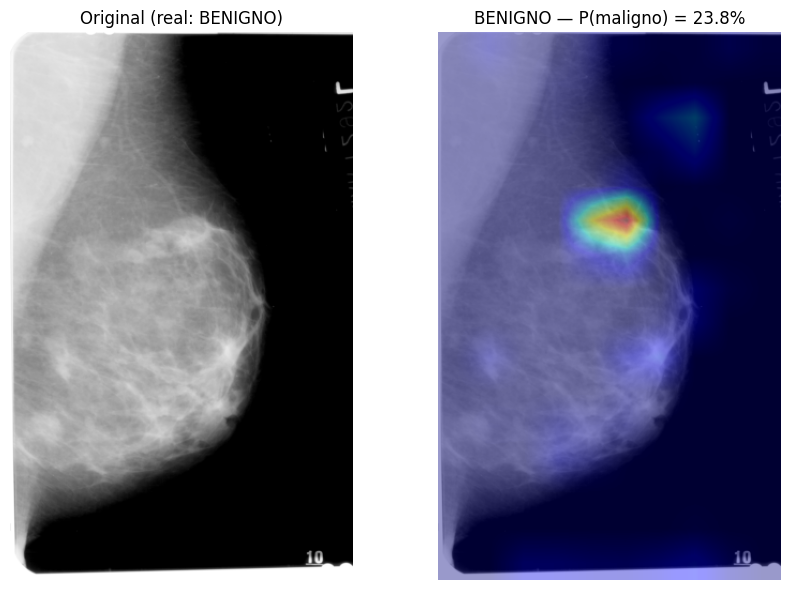

{'prediccion': 'BENIGNO', 'prob_maligno': 0.2379349172115326, 'umbral': 0.2768046259880066}


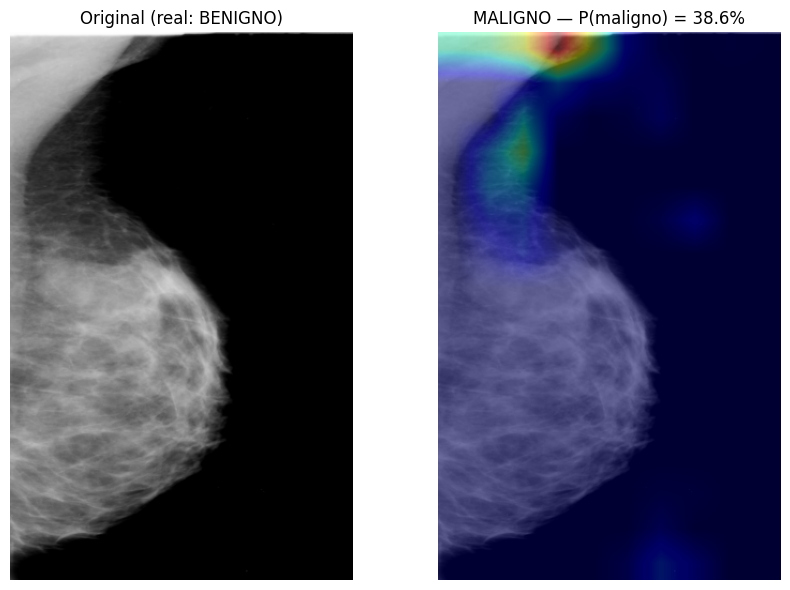

{'prediccion': 'MALIGNO', 'prob_maligno': 0.3857041597366333, 'umbral': 0.2768046259880066}


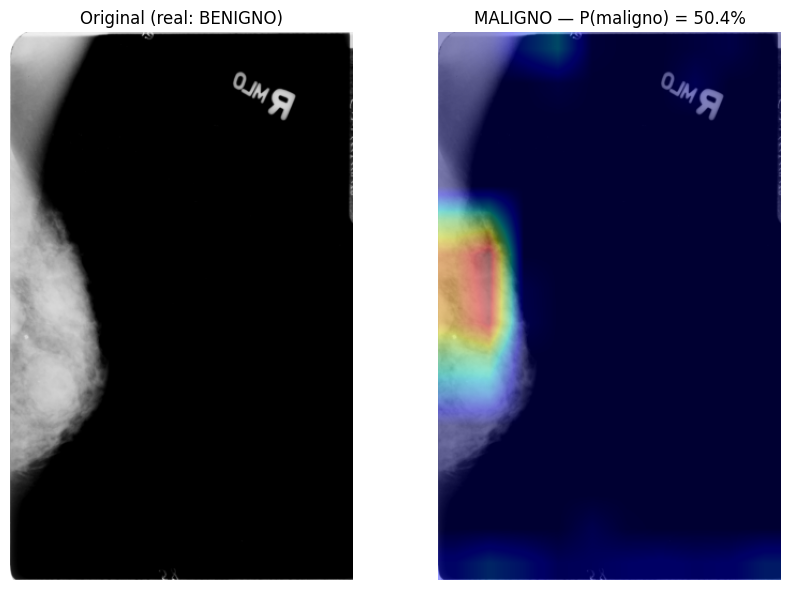

{'prediccion': 'MALIGNO', 'prob_maligno': 0.5040348768234253, 'umbral': 0.2768046259880066}


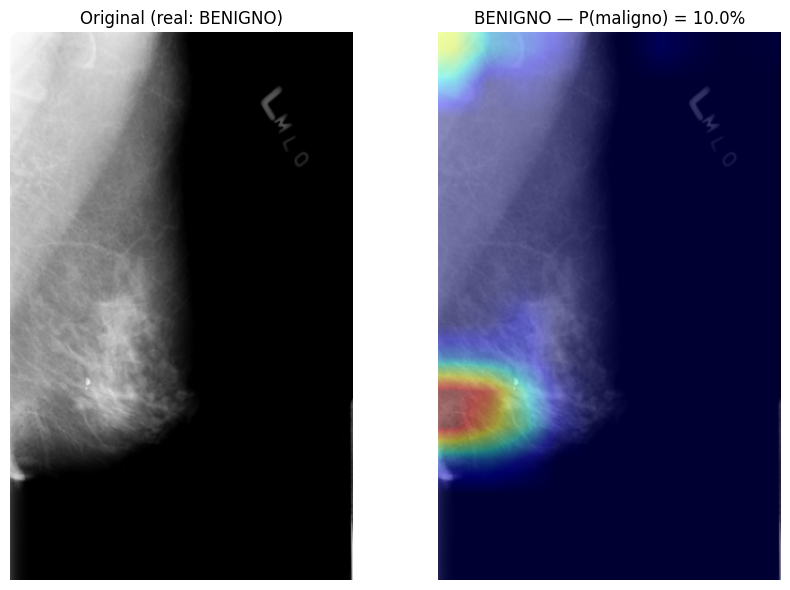

{'prediccion': 'BENIGNO', 'prob_maligno': 0.10023382306098938, 'umbral': 0.2768046259880066}


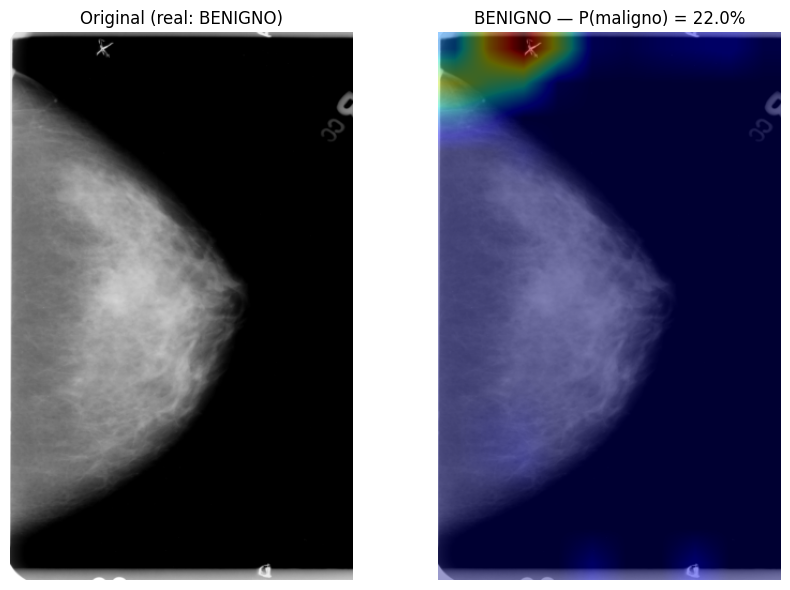

{'prediccion': 'BENIGNO', 'prob_maligno': 0.21954336762428284, 'umbral': 0.2768046259880066}


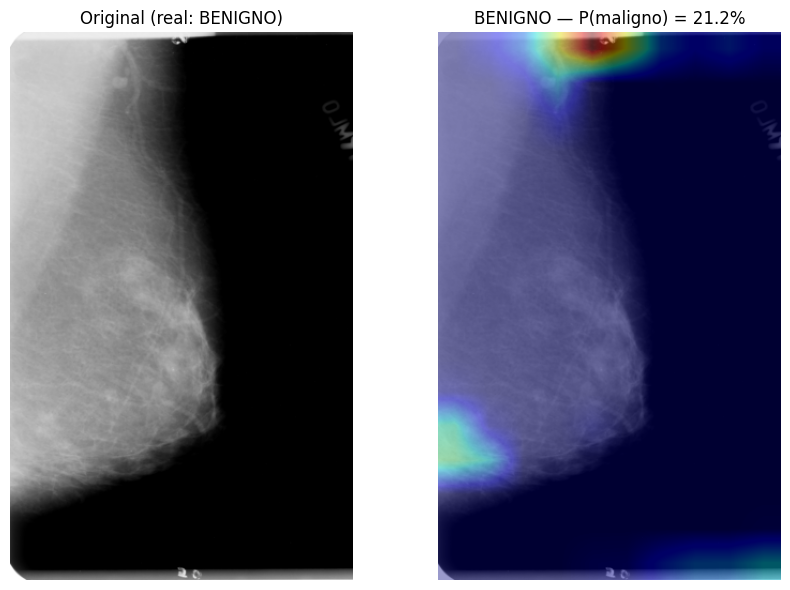

{'prediccion': 'BENIGNO', 'prob_maligno': 0.21227149665355682, 'umbral': 0.2768046259880066}


In [17]:
def _base_y_cabeza(m):
    idx = next(i for i, l in enumerate(m.layers) if isinstance(l, tf.keras.Model))
    return m.layers[idx], m.layers[idx + 1:]

def gradcam(m, x):
    base_m, cabeza = _base_y_cabeza(m)
    with tf.GradientTape() as tape:
        conv = base_m(x, training=False)
        tape.watch(conv)
        out = conv
        for capa in cabeza:
            out = capa(out, training=False)
        score = out[:, 0]
    grads = tf.cast(tape.gradient(score, conv), tf.float32)[0]
    conv = tf.cast(conv, tf.float32)[0]
    heat = tf.nn.relu(tf.reduce_sum(conv * tf.reduce_mean(grads, axis=(0, 1)), axis=-1))
    heat = heat / (tf.reduce_max(heat) + 1e-8)
    heat = tf.image.resize(heat[..., None], (IMG_H, IMG_W))[..., 0]
    return heat.numpy(), float(out[0, 0])

def predecir(ruta, etiqueta_real=None, mostrar=True):
    img_u8 = preparar_desde_bytes(tf.io.read_file(ruta))
    heat, prob = gradcam(model, a_entrada_modelo(img_u8)[None])
    pred = 'MALIGNO' if prob >= UMBRAL else 'BENIGNO'
    if mostrar:
        fig, ax = plt.subplots(1, 2, figsize=(9, 6))
        ax[0].imshow(img_u8[..., 0], cmap='gray')
        ax[0].set_title('Original' + (f" (real: {etiqueta_real})" if etiqueta_real else ''))
        ax[1].imshow(img_u8[..., 0], cmap='gray'); ax[1].imshow(heat, cmap='jet', alpha=0.4)
        ax[1].set_title(f"{pred} — P(maligno) = {prob:.1%}")
        for a in ax: a.axis('off')
        plt.tight_layout(); plt.show()
    return {'prediccion': pred, 'prob_maligno': prob, 'umbral': UMBRAL}

for _, r in pd.concat([df_test[df_test.label == 1].sample(10, random_state=1),
                       df_test[df_test.label == 0].sample(10, random_state=1)]).iterrows():
    print(predecir(r['ruta'], 'MALIGNO' if r['label'] else 'BENIGNO'))

## 12. Prueba con tus propias imágenes (jpg/png)

In [ ]:
%%script false --no-raise-error
try:
    from google.colab import files
    subidos = files.upload()
    for nombre in subidos:
        print(nombre, '→', predecir(nombre))
except ImportError:
    print("Esta celda solo funciona en Google Colab.")

## 13. Exportar para la web (modelo float32 + config + preprocesamiento)

In [ ]:
# Copia en float32 pura: más compatible y rápida en servidores sin GPU

%%script false --no-raise-error
tf.keras.mixed_precision.set_global_policy('float32')
modelo_web, _ = construir_modelo(pesos=None)
modelo_web.set_weights(model.get_weights())
RUTA_WEB = os.path.join(OUT_DIR, 'modelo_mamografia.keras')
modelo_web.save(RUTA_WEB)

x_prueba = a_entrada_modelo(preparar(df_test['ruta'].iloc[0]))[None]
dif = abs(float(modelo_web(x_prueba)[0, 0]) - float(model(x_prueba)[0, 0]))
print(f"Diferencia float32 vs original: {dif:.5f}")

config = {
    'modo': MODO, 'img_h': IMG_H, 'img_w': IMG_W,
    'umbral': UMBRAL, 'umbral_youden': UMBRAL_YOUDEN,
    'sensibilidad_objetivo': SENSIBILIDAD_OBJETIVO,
    'backbone': 'EfficientNetB0', 'salida': 'probabilidad de MALIGNO (sigmoid)',
    'entrada': 'escala de grises -> resize antialias -> [FULL] voltear si la mitad derecha es más brillante '
               '-> redondear a uint8 -> replicar a 3 canales -> float32 0-255 (SIN normalizar)',
    'metricas_test': {k: (v if isinstance(v, (list, int)) else float(v)) for k, v in r_test.items()},
    'metricas_val':  {k: (v if isinstance(v, (list, int)) else float(v)) for k, v in r_val.items()},
    'tensorflow': tf.__version__, 'keras': tf.keras.__version__ if hasattr(tf.keras, '__version__') else '',
    'dataset': 'CBIS-DDSM (awsaf49/cbis-ddsm-breast-cancer-image-dataset)',
}
with open(os.path.join(OUT_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

PREPRO = '''import json, numpy as np, tensorflow as tf

CFG = json.load(open("config.json"))
H, W, MODO = CFG["img_h"], CFG["img_w"], CFG["modo"]

def preparar_desde_bytes(raw: bytes) -> tf.Tensor:
    img = tf.io.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, (H, W), antialias=True) * 255.0
    if MODO == "FULL":
        m = W // 2
        if float(tf.reduce_sum(img[:, -m:])) > float(tf.reduce_sum(img[:, :m])):
            img = tf.image.flip_left_right(img)
    img = tf.cast(tf.clip_by_value(tf.round(img), 0, 255), tf.uint8)
    return tf.image.grayscale_to_rgb(tf.cast(img, tf.float32))[None]   # (1,H,W,3)

def predecir(model, raw: bytes) -> dict:
    p = float(model(preparar_desde_bytes(raw), training=False)[0, 0])
    return {"prediccion": "MALIGNO" if p >= CFG["umbral"] else "BENIGNO",
            "prob_maligno": p, "umbral": CFG["umbral"]}

if __name__ == "__main__":
    import sys
    model = tf.keras.models.load_model("modelo_mamografia.keras")
    print(predecir(model, open(sys.argv[1], "rb").read()))
'''
with open(os.path.join(OUT_DIR, 'preprocesamiento.py'), 'w') as f:
    f.write(PREPRO)

ZIP = '/content/modelo_mamografia_web.zip' if os.path.isdir('/content') else os.path.join(OUT_DIR, 'modelo_web.zip')
with zipfile.ZipFile(ZIP, 'w', zipfile.ZIP_DEFLATED) as z:
    for n in ['modelo_mamografia.keras', 'config.json', 'preprocesamiento.py']:
        z.write(os.path.join(OUT_DIR, n), n)
print("📦 Paquete listo:", ZIP, f"({os.path.getsize(ZIP) / 1e6:.1f} MB)")
print(json.dumps(config['metricas_test'], indent=2))

try:
    from google.colab import files
    files.download(ZIP)
except ImportError:
    pass

## ✅ Listo
Descargaste `modelo_mamografia_web.zip` con:
- `modelo_mamografia.keras` — el modelo (float32, apto para CPU).
- `config.json` — tamaño de entrada, **umbral** y métricas.
- `preprocesamiento.py` — el preprocesamiento idéntico al entrenamiento + `predecir()`. Pruébalo con `python preprocesamiento.py imagen.jpg`.

**Cómo leer los resultados:** la métrica principal es el **AUC en TEST** con su intervalo de confianza. En mamografía completa de CBIS-DDSM, un AUC de ~0.70–0.80 es un resultado razonable; en modo `ROI` suele ser más alto.

**Limitaciones:** el modelo asume que la mamografía **tiene una lesión** (no hay clase "normal"), y CBIS-DDSM son películas digitalizadas de los 90, así que puede rendir peor con mamografías digitales modernas.